# Winograd convolution

So, the english is not very good, I will improve that

In [1]:

import sympy as sy
import numpy as np

In [2]:
import fitz

from utils import plot_pdf

In [3]:
doc = fitz.open('/home/tarsio/zotero-lib/AUTH/Blahut/Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.
Is an excellent book but full of examples but, of course, do not explain everything in details.
For that parts I will quote another books and videos from Youtube.

In this tutorial I will quote the theoretical first and the example after that for best understanding.

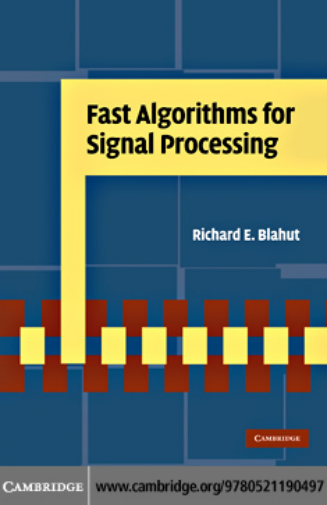

In [4]:
plot_pdf(doc[0], dpi=100)

## Polynomials

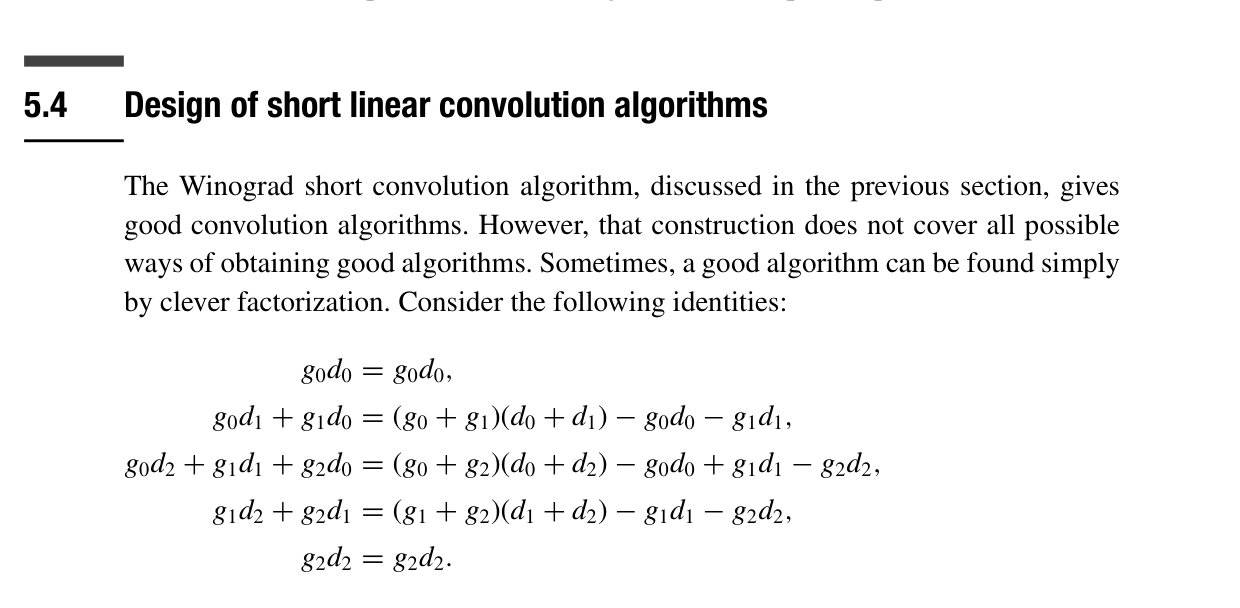

In [5]:
plot_pdf(doc[179], [.43, .75])

In [6]:
def symmetrical_polynomial_factorization(polynomial, di, gi):
    quo, rem = np.divmod(len(polynomial.args), 2)
    if rem == 0:
        args = polynomial.args
    else:
        args = [i for e, i in enumerate(polynomial.args) if sum([quo, rem])-1 != e]
    pol_idx = [e for e, c in enumerate(di) for d in args if d.coeff(c, 1) != 0]
    prod = np.prod([np.sum([(c[i]) for i in pol_idx]) for c in [di, gi]])
    s = prod - (prod.expand() - polynomial)
    return s


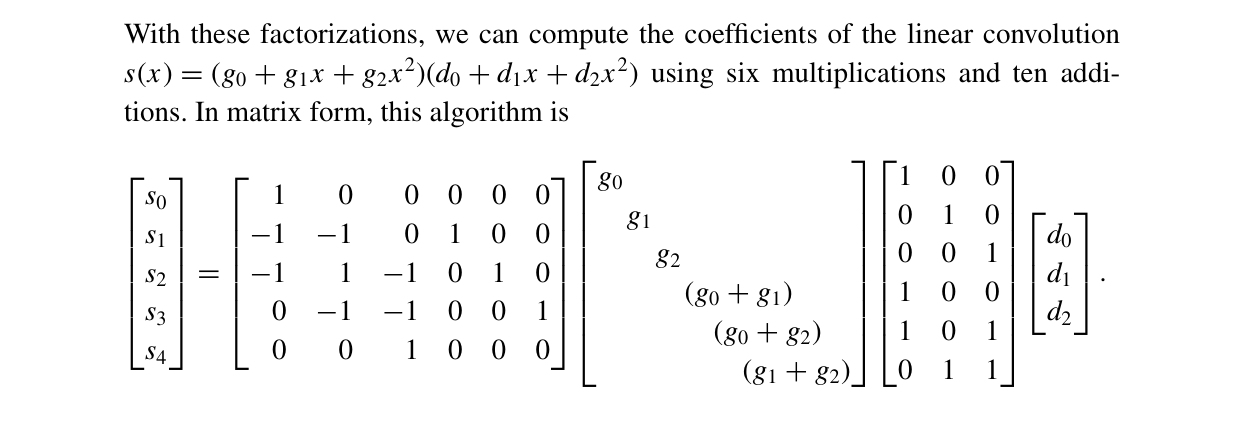

In [7]:
plot_pdf(doc[179], [.74, .97])

Size of vectors

In [8]:
d_num = 3
g_num = 3

Example of vectors for the convolution

In [9]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2, 3] [1, 2, 3]


Polynomial degree

In [10]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

2 2


In [11]:
x = sy.symbols("x")
x

x

In [32]:
di = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num))))
di

Matrix([
[d_0],
[d_1],
[d_2]])

In [13]:
gi = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num))))
gi

Matrix([
[g_0],
[g_1],
[g_2]])

In [14]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

d_0 + d_1*x + d_2*x**2

In [15]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

g_0 + g_1*x + g_2*x**2

In [16]:
sx = gx*dx
sx

(d_0 + d_1*x + d_2*x**2)*(g_0 + g_1*x + g_2*x**2)

In [17]:
dg = sy.expand(sum(gi)*sum(di))
dg

d_0*g_0 + d_0*g_1 + d_0*g_2 + d_1*g_0 + d_1*g_1 + d_1*g_2 + d_2*g_0 + d_2*g_1 + d_2*g_2

In [18]:
conv = sy.Matrix(np.convolve(np.array(di).reshape(-1), np.array(gi).reshape(-1)))
conv

Matrix([
[                    d_0*g_0],
[          d_0*g_1 + d_1*g_0],
[d_0*g_2 + d_1*g_1 + d_2*g_0],
[          d_1*g_2 + d_2*g_1],
[                    d_2*g_2]])

Resolvi isso com teoria de grupos

Os conjuntos $d$ e $g$ são os mesmos mas invertidos,
um se move no senti horário e outro no sentido inverso.

Então não preciso fazer operação em ambos mas somente em um e inverter o outro

Uma boa forma de demonstrar isso é usando dois triangulos, caso de polinômio de grau 2,
ou um vetor de 3 posições, se movendo mas o segundo triangulo se movendo no sentido
contrário

In [19]:
s0 = [symmetrical_polynomial_factorization(i, di, gi) for i in conv[1:-1]]
si = sy.Matrix([conv[0]] + s0 + [conv[-1]])
si

Matrix([
[                                               d_0*g_0],
[          -d_0*g_0 - d_1*g_1 + (d_0 + d_1)*(g_0 + g_1)],
[-d_0*g_0 + d_1*g_1 - d_2*g_2 + (d_0 + d_2)*(g_0 + g_2)],
[          -d_1*g_1 - d_2*g_2 + (d_1 + d_2)*(g_1 + g_2)],
[                                               d_2*g_2]])

In [52]:
c_args = [i.args for i in si]
c_args

[(d_0, g_0),
 ((d_0 + d_1)*(g_0 + g_1), -d_0*g_0, -d_1*g_1),
 (d_1*g_1, (d_0 + d_2)*(g_0 + g_2), -d_0*g_0, -d_2*g_2),
 ((d_1 + d_2)*(g_1 + g_2), -d_1*g_1, -d_2*g_2),
 (d_2, g_2)]

In [21]:
args = sorted(
    list(dict.fromkeys((-1)*ii if str(ii).startswith("-") else ii for i in c_args[1:-1] for ii in i)),
    key=lambda i: len(str(i))
)
args

[d_0*g_0,
 d_1*g_1,
 d_2*g_2,
 (d_0 + d_1)*(g_0 + g_1),
 (d_0 + d_2)*(g_0 + g_2),
 (d_1 + d_2)*(g_1 + g_2)]

In [41]:
# s_sym = sy.Matrix([[a if s.coeff(a, 1) != 0 else 0 for a in args] for s in si])
# s_sym

Matrix([
[d_0*g_0,       0,       0,                       0,                       0,                       0],
[d_0*g_0, d_1*g_1,       0, (d_0 + d_1)*(g_0 + g_1),                       0,                       0],
[d_0*g_0, d_1*g_1, d_2*g_2,                       0, (d_0 + d_2)*(g_0 + g_2),                       0],
[      0, d_1*g_1, d_2*g_2,                       0,                       0, (d_1 + d_2)*(g_1 + g_2)],
[      0,       0, d_2*g_2,                       0,                       0,                       0]])

In [112]:
a_mtx = sy.Matrix([[1 if s.coeff(a, 1) != 0 else 0 for a in di] for s in sy.Matrix(args).expand()])
a_mtx

Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1],
[1, 1, 0],
[1, 0, 1],
[0, 1, 1]])

In [117]:
b_mtx = sy.Matrix([[1 if s.coeff(a, 1) != 0 else 0 for a in gi] for s in sy.Matrix(args).expand()])
b_mtx

Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1],
[1, 1, 0],
[1, 0, 1],
[0, 1, 1]])

In [118]:
c_mtx = sy.Matrix([[s.coeff(a, 1) for a in args] for s in si])
c_mtx

Matrix([
[ 1,  0,  0, 0, 0, 0],
[-1, -1,  0, 1, 0, 0],
[-1,  1, -1, 0, 1, 0],
[ 0, -1, -1, 0, 0, 1],
[ 0,  0,  1, 0, 0, 0]])

sympy.core.mul.Mul